# Experiment 1 — X Chromosome: Supervised & Unsupervised ML

**Goal:**
- **Supervised:** Predict super-population label (AFR, AMR, EAS, EUR, SAS) from per-sample genotype data.
- **Unsupervised:** Apply K-Means (k=5) to discover population clusters without labels.

**Pipeline:**
1. Stream all 3.4M QC-passed X chromosome variants in chunks
2. Sex-aware genotype encoding (females diploid, males hemizygous)
3. Incremental Gram-matrix PCA on MPS GPU — no subsampling, all data used
4. Supervised classifiers: Logistic Regression, SVM, Random Forest, Decision Tree, KNN
5. K-Means clustering (k=5) with ARI & NMI evaluation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ──────────────────────────────────────────────────────────────────
BASE      = "/Users/aaditya/VS Code/1000 genome project"
CSV_PATH  = f"{BASE}/Data/chrX_full.csv"
QC_PATH   = f"{BASE}/Code/chrX_variant_summary_qc.csv"
PANEL     = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR   = f"{BASE}/Output /"

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f"Using device : {device}")
print("Imports OK")

Using device : mps
Imports OK


## 1. Load Panel & QC Variant List

In [2]:
# ── Population panel ───────────────────────────────────────────────────────
panel = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'super_pop', 'gender'])
panel = panel.rename(columns={'super_pop': 'label'})
sex_map = panel.set_index('sample')['gender'].to_dict()   # sample → 'male'/'female'

print(f"Panel samples : {len(panel):,}")
print(panel['label'].value_counts())
print(panel['gender'].value_counts())

# ── QC-passed variant positions (3.4M) ────────────────────────────────────
vs_clean = pd.read_csv(QC_PATH, usecols=['POS'])
qc_pos   = set(vs_clean['POS'].astype(str).values)
print(f"\nQC-passed variants : {len(qc_pos):,}")

Panel samples : 2,504
label
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64
gender
female    1271
male      1233
Name: count, dtype: int64

QC-passed variants : 3,434,403


## 2. Detect Sample Columns & Sex

In [3]:
META_COLS = {'#CHROM','CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT'}

header_chunk = pd.read_csv(CSV_PATH, nrows=0, low_memory=False)
header_chunk.columns = [c.strip().lstrip('\ufeff') for c in header_chunk.columns]

all_sample_cols = [c for c in header_chunk.columns if c not in META_COLS]

# Keep only samples present in panel
panel_samples = set(panel['sample'].values)
sample_cols   = [c for c in all_sample_cols if c in panel_samples]

# Build ordered arrays aligned to sample_cols
sample_arr  = np.array(sample_cols)
is_male     = np.array([sex_map.get(s, 'female') == 'male' for s in sample_cols])
n_samples   = len(sample_cols)

# Labels aligned to sample_cols
label_map   = panel.set_index('sample')['label'].to_dict()
y_str       = np.array([label_map[s] for s in sample_cols])
le          = LabelEncoder()
y           = le.fit_transform(y_str)

print(f"Samples in matrix : {n_samples:,}")
print(f"Males : {is_male.sum():,} | Females : {(~is_male).sum():,}")
print(f"Classes : {le.classes_}")

Samples in matrix : 2,504
Males : 1,233 | Females : 1,271
Classes : ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']


## 3. Incremental Gram-Matrix PCA (All 3.4M Variants, MPS GPU)

**Why Gram matrix?**  
We have 2,504 samples × 3.4M variants. Standard PCA would need to hold the full matrix in RAM (~50 GB). Instead we compute:

$$G = (X - \mu)(X - \mu)^T \quad \text{shape: } 2504 \times 2504$$

incrementally chunk-by-chunk on GPU, then eigendecompose G once. The eigenvectors of G give us the PCA scores directly.

In [4]:
# Sex-aware genotype → dosage (0 / 0.5 / 1 scale)
GT_FEMALE = {'0|0':0.0,'0/0':0.0,'0|1':0.5,'1|0':0.5,'0/1':0.5,'1/0':0.5,
             '1|1':1.0,'1/1':1.0,'.':np.nan,'.|.':np.nan,'./.':np.nan}
GT_MALE   = {'0':0.0,'1':1.0,'.':np.nan}   # hemizygous

def parse_gt(val, male):
    s = str(val).split(':')[0]
    return GT_MALE.get(s, GT_FEMALE.get(s, np.nan)) if male else GT_FEMALE.get(s, np.nan)

CHUNK_SIZE = 50_000
N_COMPONENTS = 50

# Accumulators (on CPU first, move to GPU per chunk)
col_sum  = np.zeros(n_samples, dtype=np.float64)   # for mean
col_count= np.zeros(n_samples, dtype=np.float64)   # non-NaN count
G_cpu    = np.zeros((n_samples, n_samples), dtype=np.float64)  # Gram matrix

t0 = time.time()
chunks_processed = 0
variants_used    = 0

print("Computing Gram matrix G = X X^T over all QC-passed variants...")

cols_to_read = ['POS'] + sample_cols

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE,
                          low_memory=False, dtype=str):
    chunk.columns = [c.strip().lstrip('\ufeff') for c in chunk.columns]

    # Filter to QC-passed positions
    pos_col = 'POS' if 'POS' in chunk.columns else chunk.columns[1]
    mask    = chunk[pos_col].astype(str).isin(qc_pos)
    chunk   = chunk[mask]
    if chunk.empty:
        continue

    # Keep only sample columns present in this chunk
    present = [c for c in sample_cols if c in chunk.columns]
    if not present:
        continue

    # Encode genotypes: shape (n_variants_in_chunk, n_samples)
    G_chunk = np.full((len(chunk), n_samples), np.nan, dtype=np.float32)
    for j, col in enumerate(sample_cols):
        if col not in chunk.columns:
            continue
        male = bool(is_male[j])
        G_chunk[:, j] = [parse_gt(v, male) for v in chunk[col].values]

    # Impute NaN with column mean (per variant across samples)
    col_means = np.nanmean(G_chunk, axis=1, keepdims=True)
    nan_mask  = np.isnan(G_chunk)
    G_chunk[nan_mask] = np.take(col_means.squeeze(), np.where(nan_mask)[0])

    # Accumulate for global mean
    col_sum   += G_chunk.sum(axis=0)
    col_count += G_chunk.shape[0]

    # Accumulate Gram matrix on MPS: G += chunk.T @ chunk
    t_chunk = torch.tensor(G_chunk, dtype=torch.float32, device=device)  # (variants, samples)
    G_cpu  += (t_chunk.T @ t_chunk).cpu().numpy().astype(np.float64)

    variants_used    += len(chunk)
    chunks_processed += 1

    if chunks_processed % 10 == 0:
        elapsed = time.time() - t0
        print(f"  Chunk {chunks_processed:>4} | Variants used: {variants_used:>9,} | "
              f"Elapsed: {elapsed/60:.1f} min", flush=True)

elapsed = time.time() - t0
print(f"\nDone. {variants_used:,} variants processed in {elapsed/60:.1f} min")

Computing Gram matrix G = X X^T over all QC-passed variants...
  Chunk   10 | Variants used:   496,660 | Elapsed: 10.3 min
  Chunk   20 | Variants used:   993,996 | Elapsed: 20.5 min
  Chunk   30 | Variants used: 1,491,353 | Elapsed: 30.6 min
  Chunk   40 | Variants used: 1,988,896 | Elapsed: 40.5 min
  Chunk   50 | Variants used: 2,486,351 | Elapsed: 50.5 min
  Chunk   60 | Variants used: 2,983,691 | Elapsed: 60.4 min
  Chunk   70 | Variants used: 3,449,249 | Elapsed: 69.9 min

Done. 3,449,249 variants processed in 69.9 min


In [5]:
# ── Centre the Gram matrix: G_centred = G - n*mu*mu^T ─────────────────────
mu        = col_sum / col_count                  # global mean per sample (shape: n_samples)
n_var     = float(variants_used)
G_centred = G_cpu - n_var * np.outer(mu, mu)    # centred Gram matrix

# ── Eigendecomposition ────────────────────────────────────────────────────
print("Running eigendecomposition on Gram matrix (2504×2504)...")
t1 = time.time()

eigenvalues, eigenvectors = np.linalg.eigh(G_centred)   # ascending order

# Reverse to descending (largest eigenvalue first)
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# Keep top N_COMPONENTS
eigenvalues  = eigenvalues[:N_COMPONENTS]
eigenvectors = eigenvectors[:, :N_COMPONENTS]   # shape: (n_samples, N_COMPONENTS)

# PCA scores = eigenvectors scaled by sqrt(eigenvalue)
X_pca = eigenvectors * np.sqrt(np.maximum(eigenvalues, 0))

# Explained variance ratio
total_var    = np.linalg.eigvalsh(G_centred).sum()
explained    = eigenvalues / total_var
cum_var      = np.cumsum(explained)

print(f"Eigendecomposition done in {time.time()-t1:.1f}s")
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")
print(f"PC1: {explained[0]*100:.1f}%  |  PC2: {explained[1]*100:.1f}%")

Running eigendecomposition on Gram matrix (2504×2504)...
Eigendecomposition done in 1.1s
Variance explained by 50 PCs: 66.7%
PC1: 55.2%  |  PC2: 4.8%


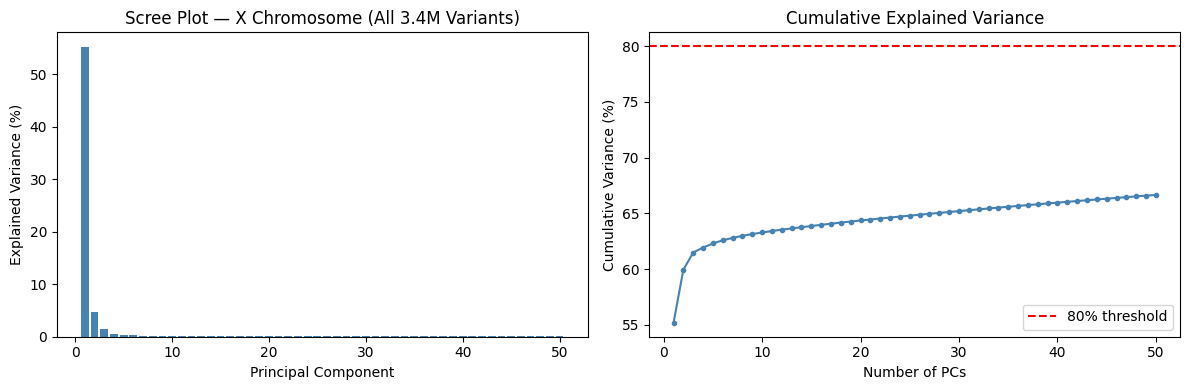

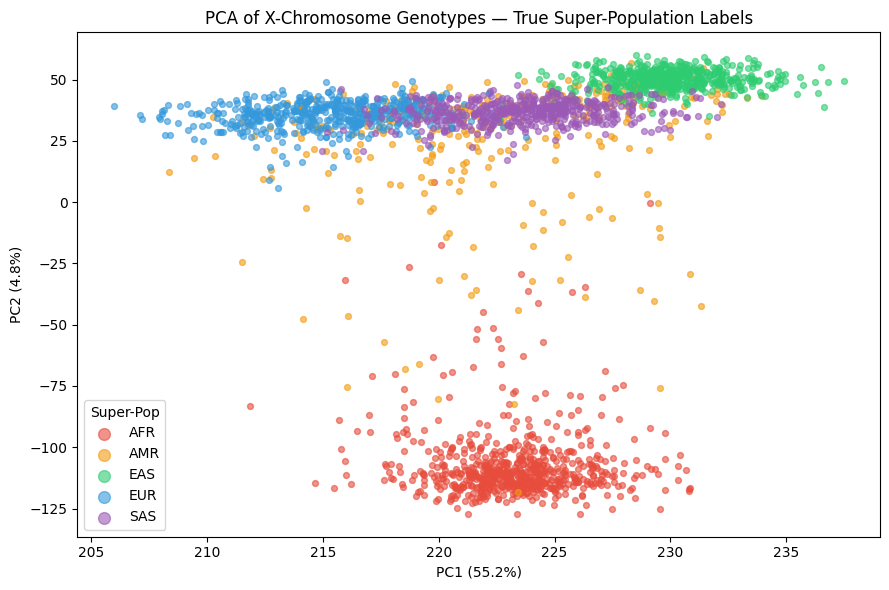

In [6]:
# ── Scree + Cumulative variance plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, N_COMPONENTS + 1), explained * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — X Chromosome (All 3.4M Variants)')

axes[1].plot(range(1, N_COMPONENTS + 1), cum_var * 100, marker='o', markersize=3, color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── PCA scatter coloured by true super-pop ────────────────────────────────
POP_COLORS = {'AFR':'#E74C3C','AMR':'#F39C12','EAS':'#2ECC71','EUR':'#3498DB','SAS':'#9B59B6'}

plt.figure(figsize=(9, 6))
for pop in le.classes_:
    mask = y_str == pop
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=POP_COLORS[pop], label=pop, alpha=0.6, s=18)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title("PCA of X-Chromosome Genotypes — True Super-Population Labels")
plt.legend(title='Super-Pop', markerscale=2)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_pca_true_labels.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Supervised Classification

In [7]:
X_train, X_test, y_train, y_test, y_train_str, y_test_str = train_test_split(
    X_pca, y, y_str, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

unique, counts = np.unique(y_train_str, return_counts=True)
print("Train class distribution:", dict(zip(unique, counts)))

Train: 2003 samples | Test: 501 samples
Train class distribution: {np.str_('AFR'): np.int64(529), np.str_('AMR'): np.int64(278), np.str_('EAS'): np.int64(403), np.str_('EUR'): np.int64(402), np.str_('SAS'): np.int64(391)}


In [8]:
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, solver='lbfgs', C=1.0, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1),
}

results       = []
trained_models = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")

    clf.fit(X_train, y_train)
    trained_models[name] = clf

    y_pred   = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    cv_scores= cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results.append({
        'Model'        : name,
        'Test Accuracy': round(test_acc, 4),
        'CV Mean'      : round(cv_scores.mean(), 4),
        'CV Std'       : round(cv_scores.std(), 4),
    })
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


──────────────────────────────────────────────────
Training: Logistic Regression
  Test Accuracy : 0.9521
  CV Accuracy   : 0.9730 ± 0.0106
              precision    recall  f1-score   support

         AFR       0.96      0.98      0.97       132
         AMR       0.81      0.87      0.84        69
         EAS       1.00      1.00      1.00       101
         EUR       0.96      0.88      0.92       101
         SAS       1.00      0.99      0.99        98

    accuracy                           0.95       501
   macro avg       0.94      0.95      0.94       501
weighted avg       0.95      0.95      0.95       501


──────────────────────────────────────────────────
Training: SVM (RBF)
  Test Accuracy : 0.9860
  CV Accuracy   : 0.9850 ± 0.0084
              precision    recall  f1-score   support

         AFR       0.97      1.00      0.99       132
         AMR       1.00      0.90      0.95        69
         EAS       1.00      1.00      1.00       101
         EUR       0.9


=== Model Comparison ===
              Model  Test Accuracy  CV Mean  CV Std
          SVM (RBF)         0.9860   0.9850  0.0084
      Random Forest         0.9721   0.9755  0.0097
          KNN (k=5)         0.9701   0.9685  0.0098
      Decision Tree         0.9641   0.9596  0.0071
Logistic Regression         0.9521   0.9730  0.0106


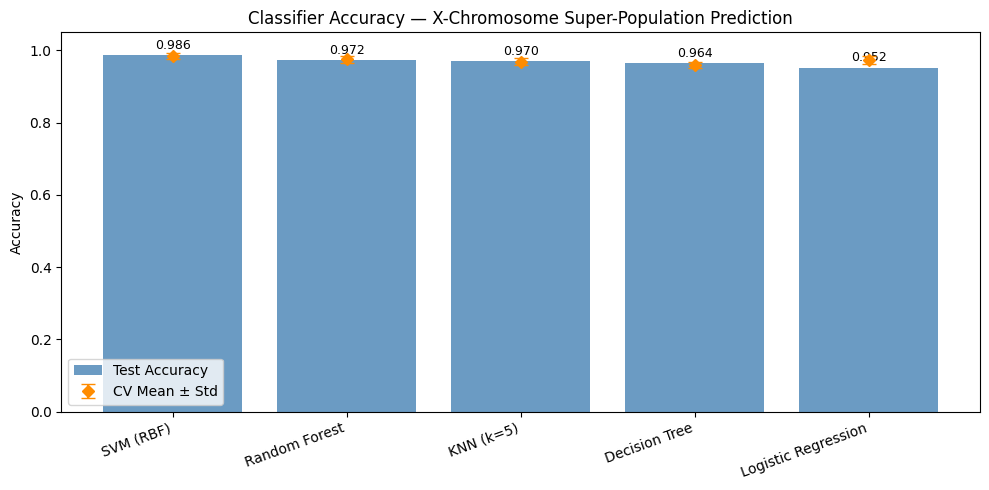

In [9]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x    = np.arange(len(results_df))
bars = ax.bar(x, results_df['Test Accuracy'], color='steelblue', alpha=0.8, label='Test Accuracy')
ax.errorbar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
            fmt='D', color='darkorange', capsize=5, label='CV Mean ± Std', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Accuracy — X-Chromosome Super-Population Prediction')
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_classifier_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

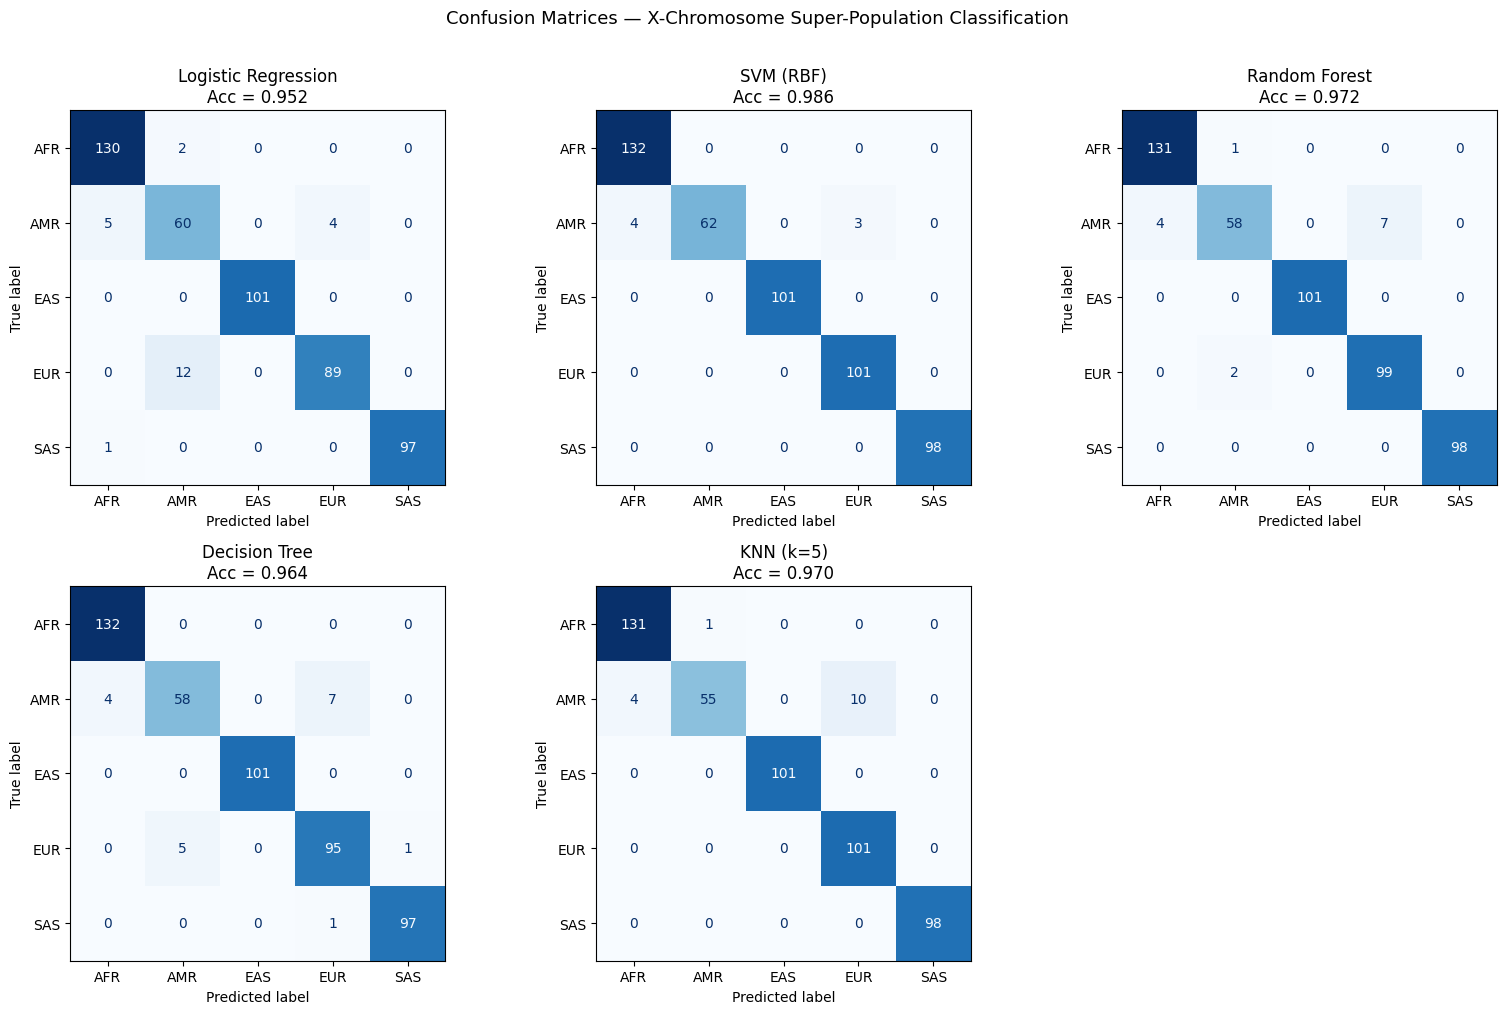

In [10]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f"{name}\nAcc = {accuracy_score(y_test, y_pred):.3f}")

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices — X-Chromosome Super-Population Classification",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Unsupervised: K-Means Clustering (k=5)

In [11]:
kmeans        = KMeans(n_clusters=5, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cluster_labels= kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)

print(f"K-Means (k=5) Results")
print(f"  ARI : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"  NMI : {nmi:.4f}  (1.0 = perfect, 0 = no shared info)")
print(f"  Inertia : {kmeans.inertia_:.2f}")

K-Means (k=5) Results
  ARI : 0.8898  (1.0 = perfect, 0 = random)
  NMI : 0.8995  (1.0 = perfect, 0 = no shared info)
  Inertia : 10737354.34



Cluster composition (counts):
true_pop  AFR  AMR  EAS  EUR  SAS
cluster                          
0           2  204    0    0    0
1         653   17    0    0    0
2           0    0    0    0  488
3           0    0  504    0    0
4           6  126    0  503    1

Cluster composition (proportions):
true_pop    AFR    AMR  EAS    EUR    SAS
cluster                                  
0         0.010  0.990  0.0  0.000  0.000
1         0.975  0.025  0.0  0.000  0.000
2         0.000  0.000  0.0  0.000  1.000
3         0.000  0.000  1.0  0.000  0.000
4         0.009  0.198  0.0  0.791  0.002


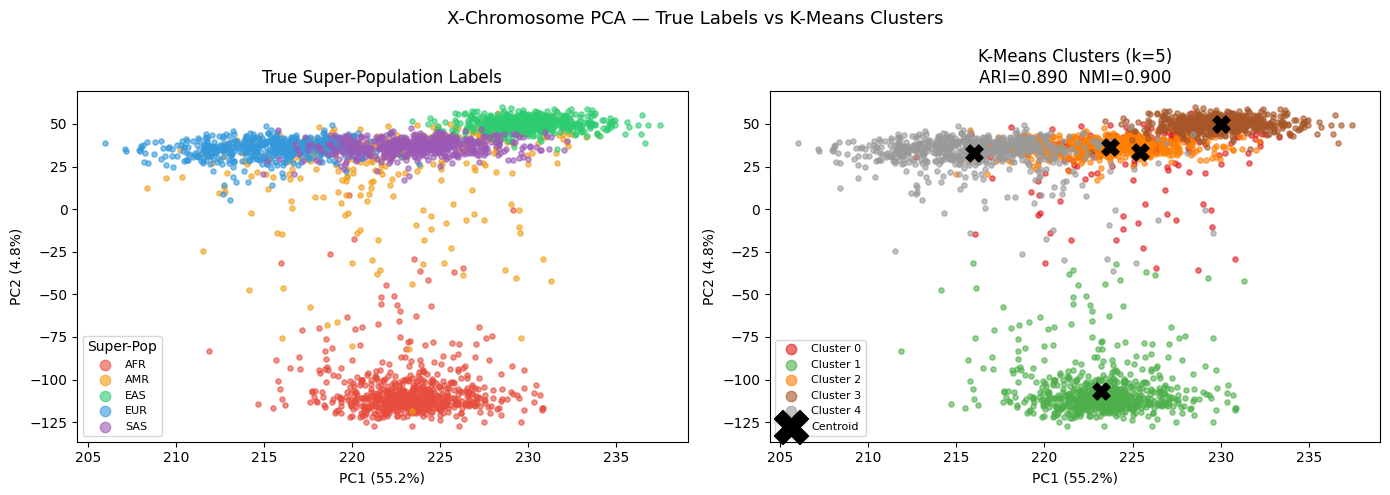

In [12]:
# Cluster composition
composition_df = pd.DataFrame({'cluster': cluster_labels, 'true_pop': y_str})
comp_table     = composition_df.groupby(['cluster','true_pop']).size().unstack(fill_value=0)
comp_pct       = comp_table.div(comp_table.sum(axis=1), axis=0).round(3)

print("\nCluster composition (counts):")
print(comp_table)
print("\nCluster composition (proportions):")
print(comp_pct)

# Side-by-side PCA scatter: True labels vs K-Means clusters
CLUSTER_COLORS = plt.cm.Set1(np.linspace(0, 1, 5))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=POP_COLORS[pop], label=pop, alpha=0.6, s=14)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("True Super-Population Labels")
axes[0].legend(title='Super-Pop', markerscale=2, fontsize=8)

for k in range(5):
    mask = cluster_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=CLUSTER_COLORS[k], label=f"Cluster {k}", alpha=0.6, s=14)
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=150, zorder=10, label='Centroid')
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title(f"K-Means Clusters (k=5)\nARI={ari:.3f}  NMI={nmi:.3f}")
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle("X-Chromosome PCA — True Labels vs K-Means Clusters", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_kmeans_vs_true.png", dpi=150, bbox_inches='tight')
plt.show()

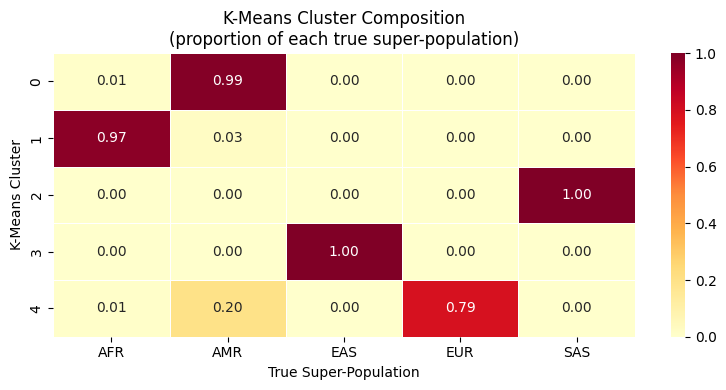

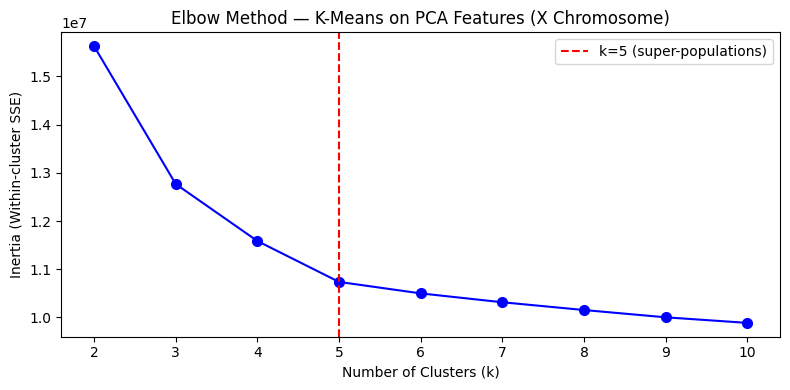

In [13]:
# Heatmap: cluster composition
plt.figure(figsize=(8, 4))
sns.heatmap(comp_pct, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, vmin=0, vmax=1)
plt.title("K-Means Cluster Composition\n(proportion of each true super-population)")
plt.xlabel("True Super-Population")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_kmeans_composition_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Elbow method
inertias = []
k_range  = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', markersize=7)
plt.axvline(x=5, color='red', linestyle='--', label='k=5 (super-populations)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method — K-Means on PCA Features (X Chromosome)')
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp1_kmeans_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Summary

In [14]:
best = results_df.iloc[0]

print("=" * 60)
print("EXPERIMENT 1 — X CHROMOSOME FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset : {n_samples:,} samples | {variants_used:,} variants | {N_COMPONENTS} PCs")
print(f"Target  : 5 super-populations — {list(le.classes_)}")
print(f"PCA variance explained : {cum_var[-1]*100:.1f}%")

print("\n── SUPERVISED (Test Accuracy) ──")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  "
          f"(CV: {row['CV Mean']:.4f} ± {row['CV Std']:.4f})")
print(f"\n  Best model: {best['Model']} (Test Acc = {best['Test Accuracy']:.4f})")

print("\n── UNSUPERVISED (K-Means, k=5) ──")
print(f"  ARI : {ari:.4f}")
print(f"  NMI : {nmi:.4f}")
print("\nAll plots saved to Output/ directory.")
print("=" * 60)

EXPERIMENT 1 — X CHROMOSOME FINAL SUMMARY

Dataset : 2,504 samples | 3,449,249 variants | 50 PCs
Target  : 5 super-populations — [np.str_('AFR'), np.str_('AMR'), np.str_('EAS'), np.str_('EUR'), np.str_('SAS')]
PCA variance explained : 66.7%

── SUPERVISED (Test Accuracy) ──
  SVM (RBF)              0.9860  (CV: 0.9850 ± 0.0084)
  Random Forest          0.9721  (CV: 0.9755 ± 0.0097)
  KNN (k=5)              0.9701  (CV: 0.9685 ± 0.0098)
  Decision Tree          0.9641  (CV: 0.9596 ± 0.0071)
  Logistic Regression    0.9521  (CV: 0.9730 ± 0.0106)

  Best model: SVM (RBF) (Test Acc = 0.9860)

── UNSUPERVISED (K-Means, k=5) ──
  ARI : 0.8898
  NMI : 0.8995

All plots saved to Output/ directory.
